# Wavelets
Everyone knows the Fourier transform where (stationary) signals are represented as a sum of sinusoids, and the standard transform is only localized in frequency. [Wavelets](https://en.wikipedia.org/wiki/Wavelet) on the other hand are localized in both time and frequency. Wavelets have proven to perform well in many ML applications on non-stationary signals. The two main approaches of using wavelets are:
* Discrete wavelet transform (DWT): A signal is broken down into subbands, from which features are extracted and used as input to ML models.
* Continuous wavelet transform (CWT): A scaleogram can be constructed from the signal. The scaleogram can be compared to a spectrogram when using FFT. Scaleogram images can then be used as input to an image classification model.  

In this notebook we will look into how to create scaleograms from bird song signatures.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import matplotlib.image as mpimg
import librosa
import warnings
warnings.filterwarnings('ignore') # get rid of librosa warnings

We could use [PyWavelets](https://pywavelets.readthedocs.io/en/latest/) for the CWT, but here we will use a modified version of [Alexander Neergaard's CWT](https://github.com/aneergaard/CWT). Specifically a parameter is added to allow cutting off the longest wavelets (lowest frequencies).

In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))
from dataprocess.cwt import cwt2, rd_file

# Automatic signature extraction
If we calculate the variance of each wavelet vector, we might use that as input to the extraction algorithm.

In [3]:
from IPython.display import Audio
from sklearn.preprocessing import minmax_scale

TRAIN_DIR = '../data/sound/cornell-birdcall/train_audio'
SR = 22050 # sample rate in Hz


In [4]:
# load a file with Black-throated Blue Warbler
d1, sr1, dura1 = rd_file(TRAIN_DIR+'/btbwar/XC139608.mp3')
Audio(d1, rate=SR)

data type: float32
data size should be 1707264.0
size of rd_file data: 1707264


Let's see how that works out for the two files.

In [5]:
# load another file with Black-throated Green Warbler
d2, sr2, dura2 = rd_file(TRAIN_DIR+'/btnwar/XC135117.mp3')
Audio(d2, rate=SR)

data type: float32
data size should be 5292000.0
size of rd_file data: 5292000


size of x: 853632, memory of x 3414528
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.8159

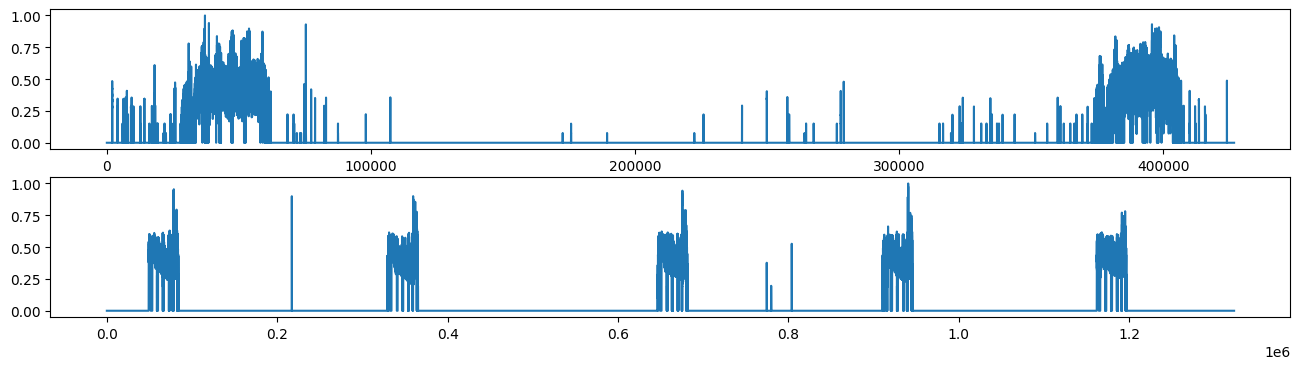

In [6]:
from cwt import calc_var

cs1, f1 = cwt2(d1, nv=12, sr=SR, low_freq=40)
cs2, f2 = cwt2(d2, nv=12, sr=SR, low_freq=40)

fig, axes = plt.subplots(2, 1, figsize=(16,4))
v1 = calc_var(cs1, -30)
axes[0].plot(v1)
v2 = calc_var(cs2, -30)
axes[1].plot(v2)
plt.show()

Scipy has a function find_peaks() that we could use to find high-energy parts of the scaleogram.

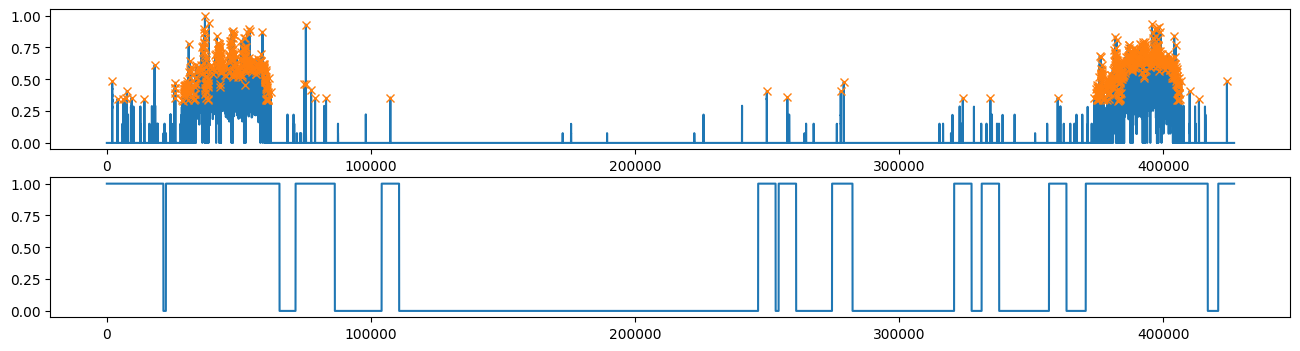

In [7]:
from cwt import find_peaks, mask_sig, get_mask, get_regions

fig, axes = plt.subplots(2, 1, figsize=(16,4))
# peak detection + gliding window
peaks, _ = find_peaks(v1, prominence=0.3)
axes[0].plot(v1)
axes[0].plot(peaks, v1[peaks], "x")
m = mask_sig(len(v1), peaks, SR, 0.3)
axes[1].plot(m)
plt.show()

Next, we extract the mask segments with other Scipy functions:

In [8]:
mask = get_mask(v1, prom=0.3, dur=0.2, sr=SR)
df = get_regions(mask, SR, 'btbwar', 'XC139608.mp3')
df.head(6)

,Start,End,Duration,Species,File
0,0,11587,0.525,btbwar,XC139608.mp3
1,12025,20281,0.374,btbwar,XC139608.mp3
2,23451,64258,1.851,btbwar,XC139608.mp3
3,72540,85198,0.574,btbwar,XC139608.mp3
4,105132,109542,0.200,btbwar,XC139608.mp3
5,247683,252093,0.200,btbwar,XC139608.mp3


We are only interested in segments of a certain length, say 1s or more:

In [9]:
df = df[df.Duration >= 1.0]
df = df.reset_index(drop=True)
df

,Start,End,Duration,Species,File
0,23451,64258,1.851,btbwar,XC139608.mp3
1,371731,415714,1.995,btbwar,XC139608.mp3


Plot those regions to check that we captured the signatures:

size of x: 88200, memory of x 352800
num of scales: 97
scales:
[  2.           2.11892619   2.2449241    2.37841423   2.5198421
   2.66967971   2.82842712   2.99661415   3.1748021    3.36358566
   3.56359487   3.77549725   4.           4.23785238   4.48984819
   4.75682846   5.0396842    5.33935942   5.65685425   5.99322831
   6.34960421   6.72717132   7.12718975   7.5509945    8.
   8.47570475   8.97969639   9.51365692  10.0793684   10.67871883
  11.3137085   11.98645662  12.69920842  13.45434264  14.25437949
  15.101989    16.          16.95140951  17.95939277  19.02731384
  20.1587368   21.35743767  22.627417    23.97291323  25.39841683
  26.90868529  28.50875898  30.20397801  32.          33.90281902
  35.91878555  38.05462768  40.3174736   42.71487533  45.254834
  47.94582646  50.79683366  53.81737058  57.01751796  60.40795601
  64.          67.80563804  71.83757109  76.10925536  80.63494719
  85.42975067  90.50966799  95.89165292 101.59366733 107.63474115
 114.03503592 120.815912

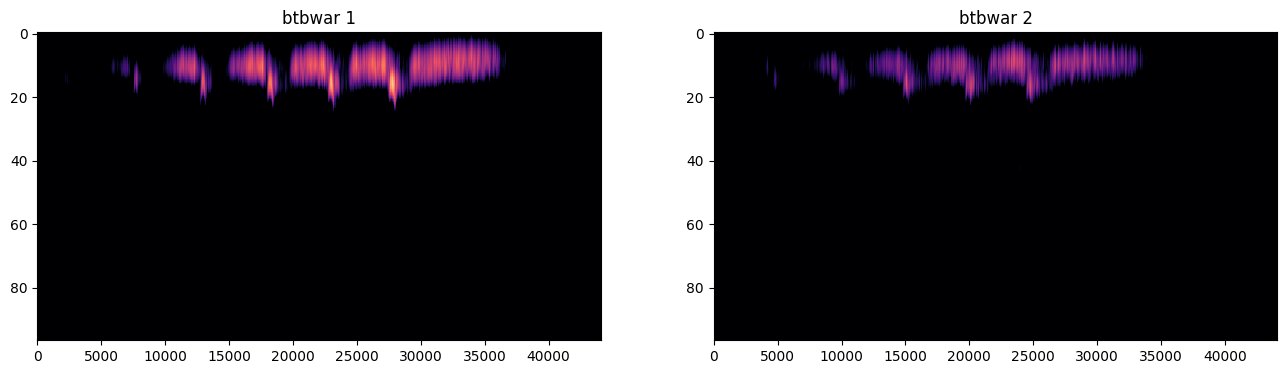

In [10]:
from cwt import plot_sigx2

# we plot two seconds
plot_sigx2(d1[df.Start[0]:df.Start[0]+2*SR], d1[df.Start[1]:df.Start[1]+2*SR], 
           name1='btbwar 1', name2='btbwar 2')

Not bad at all! Let's try the other file:

In [11]:
mask = get_mask(v2, prom=0.3, dur=0.3, sr=SR)
df = get_regions(mask, SR, 'btnwar', 'XC135117.mp3')
df = df[df.Duration >= 1.0]
df = df.reset_index(drop=True)
df

,Start,End,Duration,Species,File
0,46301,87102,1.850,btnwar,XC135117.mp3
1,343257,368307,1.136,btnwar,XC135117.mp3
2,643200,684693,1.882,btnwar,XC135117.mp3
3,907127,948970,1.898,btnwar,XC135117.mp3
4,1159409,1199695,1.827,btnwar,XC135117.mp3


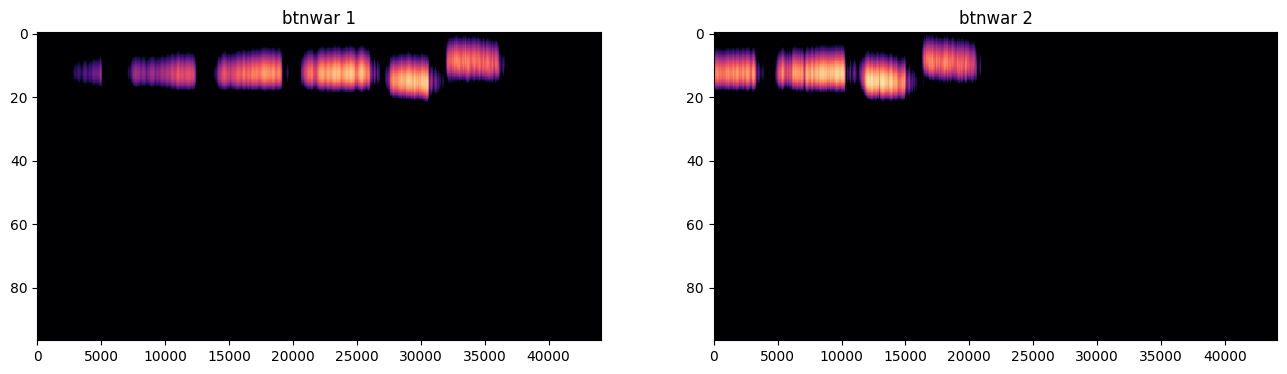

In [12]:
plot_sigx2(d2[df.Start[0]:df.Start[0]+2*SR], d2[df.Start[1]:df.Start[1]+2*SR], 
           name1='btnwar 1', name2='btnwar 2')

The second signature is clipped a bit, but that is OK. All five signatures were detected. The final step is to combine everything into a function that will extract signatures from a file and dump them as jpeg images.

A rule-based signature extraction algorithm is pretty much doomed on complex or noisy signals. A better solution is to train a binary classifier to extract signatures on a reasonable scale (1-5s), and then feed the extracted signatures to a species classifier. Breaking this problem down into two steps simplifies things a lot, and each step can be optimized independently. 

In [12]:
# free up memory
%xdel d1
%xdel d2
%xdel cs1
%xdel cs2

# Create images

Process a few files and see what we get.

In [13]:
OUT_DIR = './tmp'
%mkdir {OUT_DIR}


In [14]:
from cwt import batch_extract, scaleo_extract

flist = ['/btbwar/XC139608.mp3', '/btbwar/XC51863.mp3', '/btbwar/XC134502.mp3', '/btbwar/XC415596.mp3']
plist = [ f'{TRAIN_DIR}{f}' for f in flist ]

# 16GB RAM, set batch to 2
# 32GB RAM, set batch to 3
batch_extract(plist, OUT_DIR, batch=2)

# 47.2s
# for i in plist:
#     scaleo_extract(i, outdir='./tmp')

threshold: -30, img_size: 512
threshold: -30, img_size: 512
threshold: -30, img_size: 512
threshold: -30, img_size: 512


/Users/zhangjw/Library/Caches/pypoetry/virtualenvs/pestdataprocess-ej7BuNox-py3.10/lib/python3.10/site-packages/librosa/util/decorators.py:88: UserWarning: PySoundFile failed. Trying audioread instead.
  return f(*args, **kwargs)
/Users/zhangjw/Library/Caches/pypoetry/virtualenvs/pestdataprocess-ej7BuNox-py3.10/lib/python3.10/site-packages/librosa/util/decorators.py:88: UserWarning: PySoundFile failed. Trying audioread instead.
  return f(*args, **kwargs)
/Users/zhangjw/Library/Caches/pypoetry/virtualenvs/pestdataprocess-ej7BuNox-py3.10/lib/python3.10/site-packages/librosa/util/decorators.py:88: UserWarning: PySoundFile failed. Trying audioread instead.
  return f(*args, **kwargs)
/Users/zhangjw/Library/Caches/pypoetry/virtualenvs/pestdataprocess-ej7BuNox-py3.10/lib/python3.10/site-packages/librosa/util/decorators.py:88: UserWarning: PySoundFile failed. Trying audioread instead.
  return f(*args, **kwargs)


data type: float32
data size should be 1707264.0
size of rd_file data: 1707264
scaleo_extract, data type: float32
rd_file time: 0:00:00.868897
num of scales: 255
scales:
[  2.           2.00784314   2.01574803   2.02371542   2.03174603
   2.03984064   2.048        2.0562249    2.06451613   2.07287449
   2.08130081   2.08979592   2.09836066   2.10699588   2.11570248
   2.12448133   2.13333333   2.14225941   2.1512605    2.16033755
   2.16949153   2.1787234    2.18803419   2.19742489   2.20689655
   2.21645022   2.22608696   2.23580786   2.24561404   2.25550661
   2.26548673   2.27555556   2.28571429   2.29596413   2.30630631
   2.31674208   2.32727273   2.33789954   2.34862385   2.359447
   2.37037037   2.38139535   2.39252336   2.40375587   2.41509434
   2.42654028   2.43809524   2.44976077   2.46153846   2.47342995
   2.48543689   2.49756098   2.50980392   2.52216749   2.53465347
   2.54726368   2.56         2.57286432   2.58585859   2.59898477
   2.6122449    2.62564103   2.63917526 

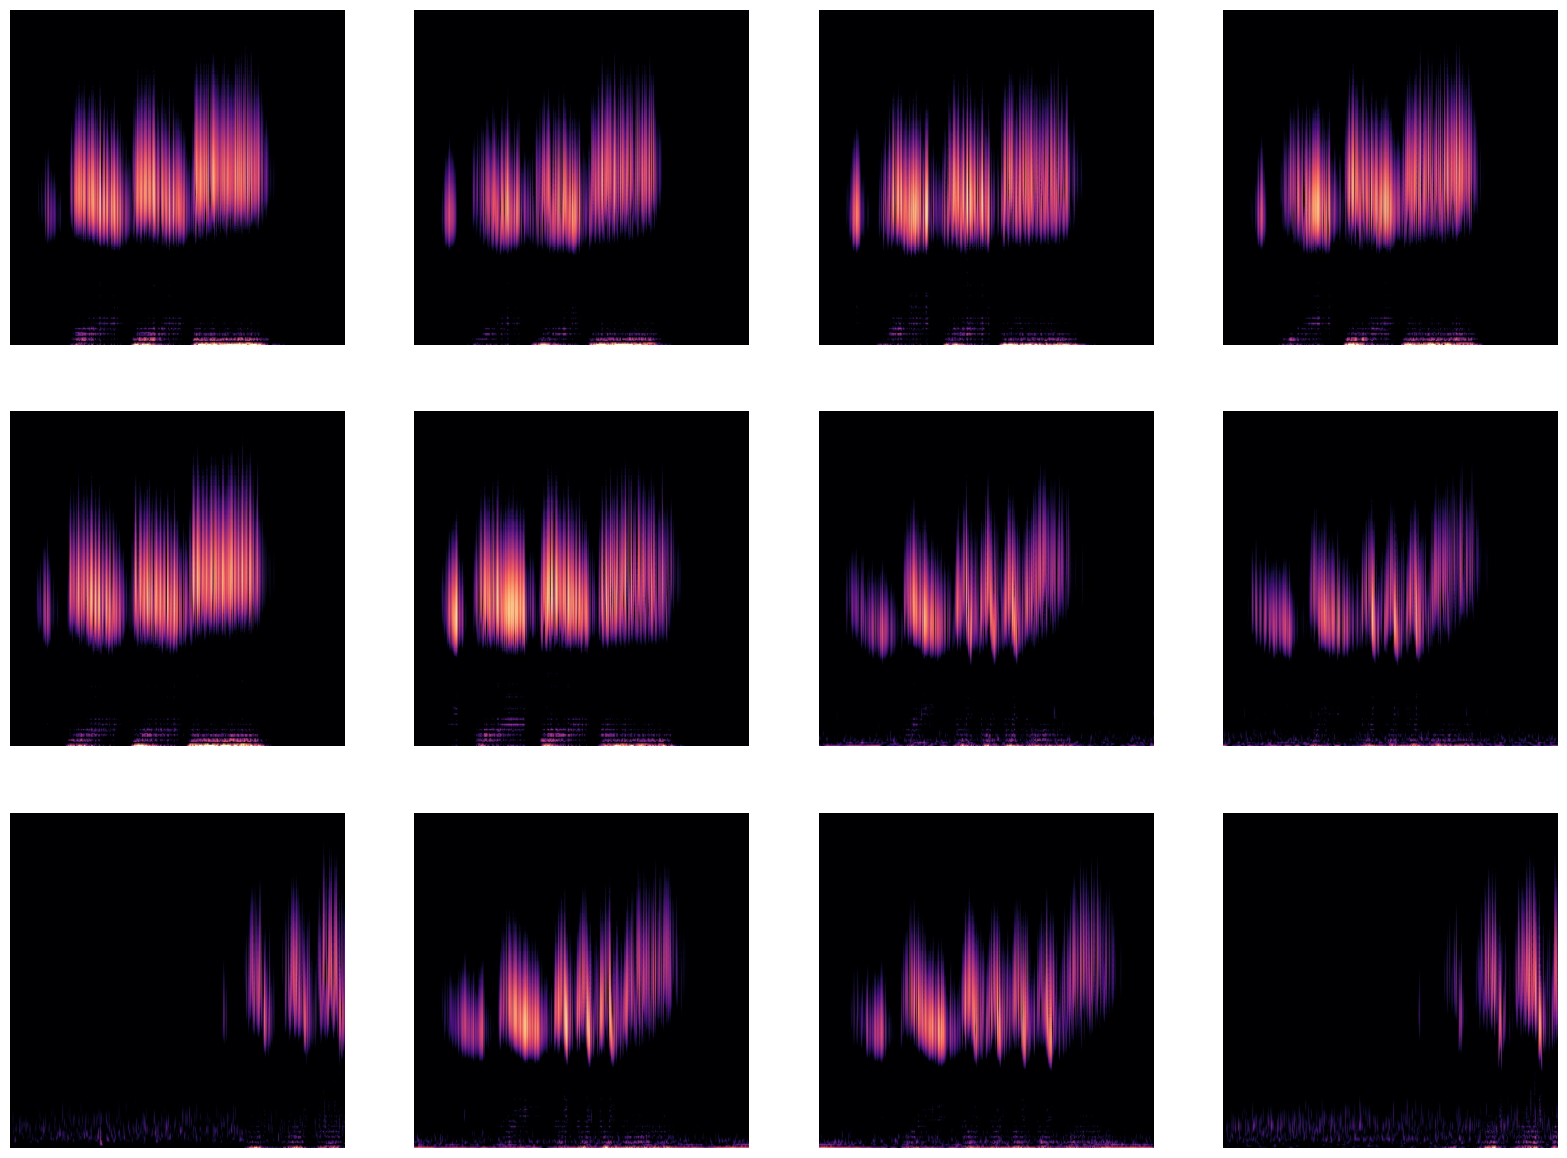

In [15]:
import glob

images = glob.glob(OUT_DIR + "/btbwar*.jpg")
plt.figure(figsize=(20,20))
columns = 4
for i, image in enumerate(images):
    plt.subplot(len(images) // columns + 1, columns, i + 1)
    plt.imshow(mpimg.imread(image))
    plt.axis('off')

Now, another warbler.

In [16]:
flist = ['/btnwar/XC135117.mp3', '/btnwar/XC135495.mp3', '/btnwar/XC173264.mp3', '/btnwar/XC501261.mp3', '/btnwar/XC486860.mp3']
# for i in flist:
#     scaleo_extract(TRAIN_DIR+i, outdir='./tmp')
plist = [ f'{TRAIN_DIR}{f}' for f in flist ]

batch_extract(plist, OUT_DIR, batch=2)

threshold: -30, img_size: 512
threshold: -30, img_size: 512


/Users/zhangjw/Library/Caches/pypoetry/virtualenvs/pestdataprocess-ej7BuNox-py3.10/lib/python3.10/site-packages/librosa/util/decorators.py:88: UserWarning: PySoundFile failed. Trying audioread instead.
  return f(*args, **kwargs)
/Users/zhangjw/Library/Caches/pypoetry/virtualenvs/pestdataprocess-ej7BuNox-py3.10/lib/python3.10/site-packages/librosa/util/decorators.py:88: UserWarning: PySoundFile failed. Trying audioread instead.
  return f(*args, **kwargs)


data type: float32
data size should be 1990656.0
size of rd_file data: 1990656
scaleo_extract, data type: float32
rd_file time: 0:00:01.078119
num of scales: 255
scales:
[  2.           2.00784314   2.01574803   2.02371542   2.03174603
   2.03984064   2.048        2.0562249    2.06451613   2.07287449
   2.08130081   2.08979592   2.09836066   2.10699588   2.11570248
   2.12448133   2.13333333   2.14225941   2.1512605    2.16033755
   2.16949153   2.1787234    2.18803419   2.19742489   2.20689655
   2.21645022   2.22608696   2.23580786   2.24561404   2.25550661
   2.26548673   2.27555556   2.28571429   2.29596413   2.30630631
   2.31674208   2.32727273   2.33789954   2.34862385   2.359447
   2.37037037   2.38139535   2.39252336   2.40375587   2.41509434
   2.42654028   2.43809524   2.44976077   2.46153846   2.47342995
   2.48543689   2.49756098   2.50980392   2.52216749   2.53465347
   2.54726368   2.56         2.57286432   2.58585859   2.59898477
   2.6122449    2.62564103   2.63917526 

/Users/zhangjw/Library/Caches/pypoetry/virtualenvs/pestdataprocess-ej7BuNox-py3.10/lib/python3.10/site-packages/librosa/util/decorators.py:88: UserWarning: PySoundFile failed. Trying audioread instead.
  return f(*args, **kwargs)


data type: float32
data size should be 5292000.0
size of rd_file data: 5292000
scaleo_extract, data type: float32
rd_file time: 0:00:00.909383
num of scales: 255
scales:
[  2.           2.00784314   2.01574803   2.02371542   2.03174603
   2.03984064   2.048        2.0562249    2.06451613   2.07287449
   2.08130081   2.08979592   2.09836066   2.10699588   2.11570248
   2.12448133   2.13333333   2.14225941   2.1512605    2.16033755
   2.16949153   2.1787234    2.18803419   2.19742489   2.20689655
   2.21645022   2.22608696   2.23580786   2.24561404   2.25550661
   2.26548673   2.27555556   2.28571429   2.29596413   2.30630631
   2.31674208   2.32727273   2.33789954   2.34862385   2.359447
   2.37037037   2.38139535   2.39252336   2.40375587   2.41509434
   2.42654028   2.43809524   2.44976077   2.46153846   2.47342995
   2.48543689   2.49756098   2.50980392   2.52216749   2.53465347
   2.54726368   2.56         2.57286432   2.58585859   2.59898477
   2.6122449    2.62564103   2.63917526 

/Users/zhangjw/Library/Caches/pypoetry/virtualenvs/pestdataprocess-ej7BuNox-py3.10/lib/python3.10/site-packages/librosa/util/decorators.py:88: UserWarning: PySoundFile failed. Trying audioread instead.
  return f(*args, **kwargs)


data type: float32
data size should be 5292000.0
size of rd_file data: 5292000
scaleo_extract, data type: float32
rd_file time: 0:00:01.156547
num of scales: 255
scales:
[  2.           2.00784314   2.01574803   2.02371542   2.03174603
   2.03984064   2.048        2.0562249    2.06451613   2.07287449
   2.08130081   2.08979592   2.09836066   2.10699588   2.11570248
   2.12448133   2.13333333   2.14225941   2.1512605    2.16033755
   2.16949153   2.1787234    2.18803419   2.19742489   2.20689655
   2.21645022   2.22608696   2.23580786   2.24561404   2.25550661
   2.26548673   2.27555556   2.28571429   2.29596413   2.30630631
   2.31674208   2.32727273   2.33789954   2.34862385   2.359447
   2.37037037   2.38139535   2.39252336   2.40375587   2.41509434
   2.42654028   2.43809524   2.44976077   2.46153846   2.47342995
   2.48543689   2.49756098   2.50980392   2.52216749   2.53465347
   2.54726368   2.56         2.57286432   2.58585859   2.59898477
   2.6122449    2.62564103   2.63917526 

/Users/zhangjw/Library/Caches/pypoetry/virtualenvs/pestdataprocess-ej7BuNox-py3.10/lib/python3.10/site-packages/librosa/util/decorators.py:88: UserWarning: PySoundFile failed. Trying audioread instead.
  return f(*args, **kwargs)


data type: float32
data size should be 5292000.0
size of rd_file data: 5292000
scaleo_extract, data type: float32
rd_file time: 0:00:00.991807
num of scales: 255
scales:
[  2.           2.00784314   2.01574803   2.02371542   2.03174603
   2.03984064   2.048        2.0562249    2.06451613   2.07287449
   2.08130081   2.08979592   2.09836066   2.10699588   2.11570248
   2.12448133   2.13333333   2.14225941   2.1512605    2.16033755
   2.16949153   2.1787234    2.18803419   2.19742489   2.20689655
   2.21645022   2.22608696   2.23580786   2.24561404   2.25550661
   2.26548673   2.27555556   2.28571429   2.29596413   2.30630631
   2.31674208   2.32727273   2.33789954   2.34862385   2.359447
   2.37037037   2.38139535   2.39252336   2.40375587   2.41509434
   2.42654028   2.43809524   2.44976077   2.46153846   2.47342995
   2.48543689   2.49756098   2.50980392   2.52216749   2.53465347
   2.54726368   2.56         2.57286432   2.58585859   2.59898477
   2.6122449    2.62564103   2.63917526 

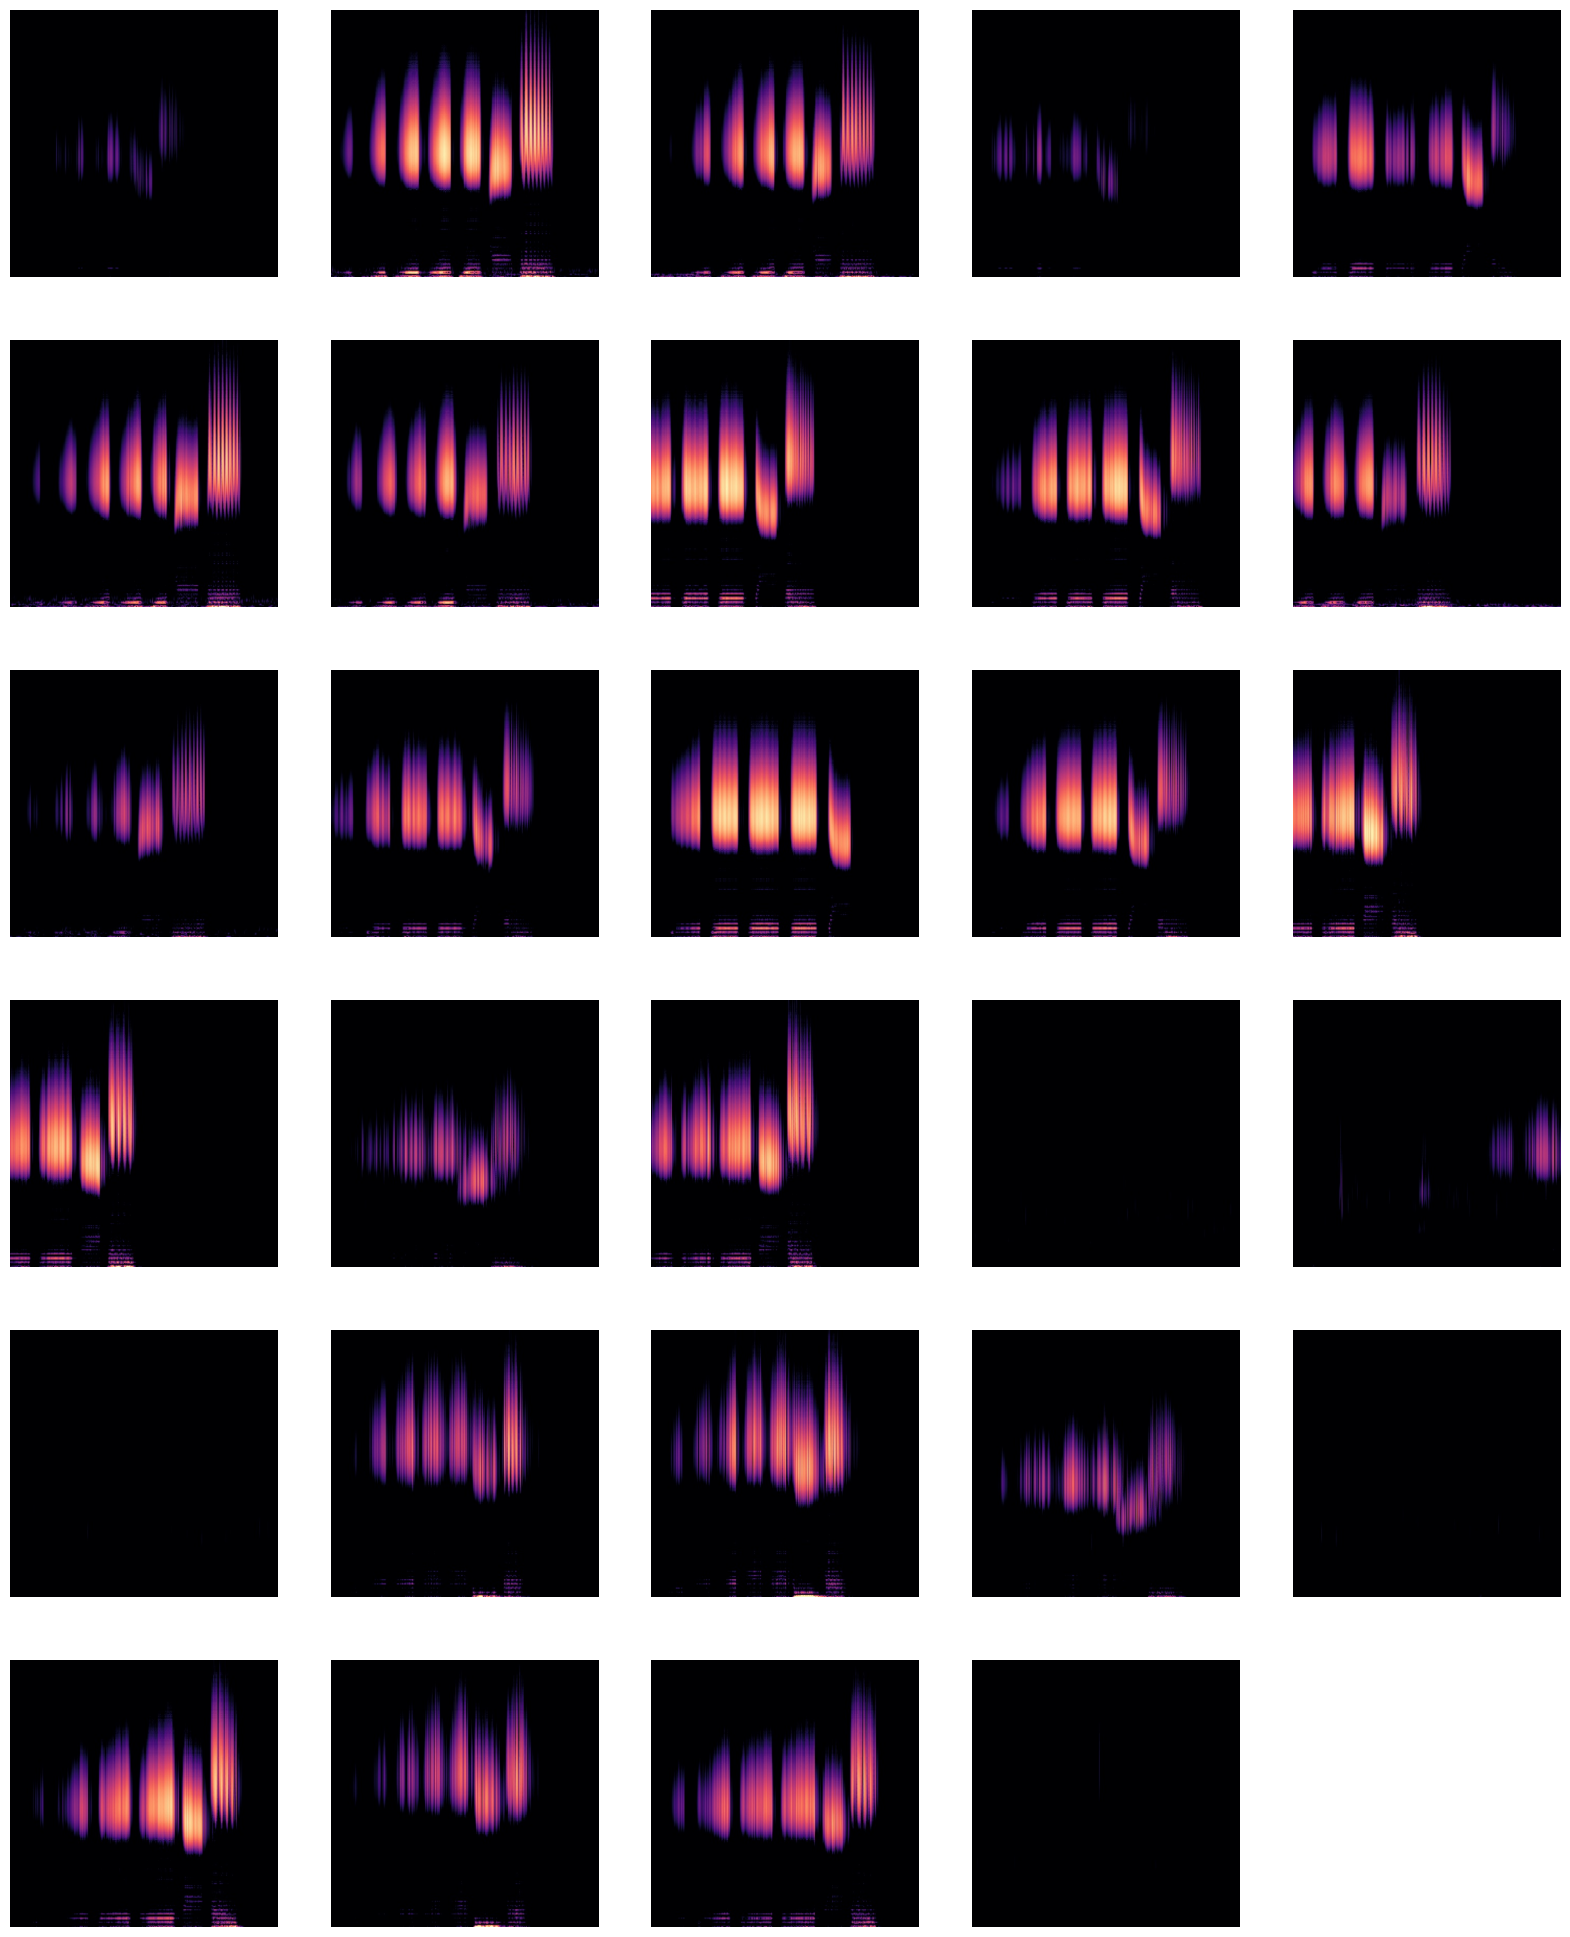

In [17]:
images = glob.glob(OUT_DIR + "/btnwar*.jpg")
plt.figure(figsize=(20,25))
columns = 5
for i, image in enumerate(images):
    plt.subplot(len(images) // columns + 1, columns, i + 1)
    plt.imshow(mpimg.imread(image))
    plt.axis('off')

We extracted 4 non-signatures from file XC501261 - should not be a problem to do a post check to detect and remove false signatures. Or better: Train an ML model (binary classifier) to detect signatures.

# Color or grayscale?
The scaleograms represent magnitude of the wavelet coefficients. Pseudo-coloring is used here for human perception. But there is really not more information here than in a grayscale image. Which colormap to use for training? Well, if we think of augmentation with brightness or contrast adjustments, those are only "correct" for grayscale. On the other hand, image models might train better with color inputs... So maybe we need to try both - or even an ensemble of the two!

# Summary
This notebook shows how to use the contiunous wavelet transform to create scaleograms from non-stationary audio signals, with the purpose of using an image classifier to detect bird species. The outline of a two-stage ML pipeline is starting to emerge:  
* Step 1: Train a binary classifier to detect and extract bird songs on a reasonable scale (1-5s)
* Step 2: Feed the bird song segments to a species classifier  

All using the wavelet transform and scaleograms of course.

In [18]:
!rm -fr {OUT_DIR}